# Supervised Learning: Stunting Classification Analysis Based on Anthropometry

In [1]:
# Import core libraries for data analysis, modeling, evaluation, class balancing, and model interpretability
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set matplotlib graphic resolution globally to 500 DPI for publication standard
mpl.rcParams['figure.dpi'] = 500
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Times New Roman'] + mpl.rcParams['font.serif']
sns.set_theme(style='whitegrid')
print("All classification libraries successfully imported with 500 DPI visualization settings!")

All classification libraries successfully imported with 500 DPI visualization settings!


/home/haerulyudaaditiya/Downloads/exp/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Child Dataset and WHO Reference Tables
We load the under-five nutritional status dataset and the WHO LMS parameter tables for boys and girls.

In [2]:
# Load main dataset
df_ml = pd.read_csv('dataset/Stunting Wasting Dataset (Synthetic)/stunting_wasting_dataset.csv')
df_ml = df_ml.rename(columns={
    'Jenis Kelamin': 'Gender',
    'Umur (bulan)': 'Age (months)',
    'Tinggi Badan (cm)': 'Height (cm)',
    'Berat Badan (kg)': 'Weight (kg)'
})
df_ml['Gender'] = df_ml['Gender'].replace({'Laki-laki': 'Male', 'Perempuan': 'Female'})

# Load WHO standard Z-score reference tables
who_lhfa_boys = pd.read_csv('dataset/Stunting Wasting Dataset (Synthetic)/z-scores who/lhfa_boys_0-to-5-years_zscores.csv', sep=';', decimal=',')
who_lhfa_girls = pd.read_csv('dataset/Stunting Wasting Dataset (Synthetic)/z-scores who/lhfa_girls_0-to-5-years_zscores.csv', sep=';', decimal=',')
who_wfa_boys = pd.read_csv('dataset/Stunting Wasting Dataset (Synthetic)/z-scores who/wfa_boys_0-to-5-years_zscores.csv', sep=';', decimal=',')
who_wfa_girls = pd.read_csv('dataset/Stunting Wasting Dataset (Synthetic)/z-scores who/wfa_girls_0-to-5-years_zscores.csv', sep=';', decimal=',')

# Standardize the first column name to 'c' (representing Age/Month)
who_lhfa_boys = who_lhfa_boys.rename(columns={who_lhfa_boys.columns[0]: 'c'})
who_lhfa_girls = who_lhfa_girls.rename(columns={who_lhfa_girls.columns[0]: 'c'})
who_wfa_boys = who_wfa_boys.rename(columns={who_wfa_boys.columns[0]: 'c'})
who_wfa_girls = who_wfa_girls.rename(columns={who_wfa_girls.columns[0]: 'c'})

print(f"Under-five child dataset loaded successfully. Total rows: {df_ml.shape[0]}, Total columns: {df_ml.shape[1]}")

Under-five child dataset loaded successfully. Total rows: 100000, Total columns: 6


## 2. Initial Data Inspection
Displays the first 5 rows to examine the dataset structure.

In [3]:
df_ml.head()

,Gender,Age (months),Height (cm),Weight (kg),Stunting,Wasting
0,Male,19,91.6,13.3,Tall,Risk of Overweight
1,Male,20,77.7,8.5,Stunted,Underweight
2,Male,10,79.0,10.3,Normal,Risk of Overweight
3,Female,2,50.3,8.3,Severely Stunted,Risk of Overweight
4,Female,5,56.4,10.9,Severely Stunted,Risk of Overweight


### 2.1 Data Types and Columns Information
Displays the data type of each column and the count of non-null values.

In [4]:
df_ml.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Gender        100000 non-null  str    
 1   Age (months)  100000 non-null  int64  
 2   Height (cm)   100000 non-null  float64
 3   Weight (kg)   100000 non-null  float64
 4   Stunting      100000 non-null  str    
 5   Wasting       100000 non-null  str    
dtypes: float64(2), int64(1), str(3)
memory usage: 4.6 MB


### 2.2 Statistical Description of the Dataset
Displays statistical summary (mean, standard deviation, minimum, and maximum values) for numerical variables.

In [5]:
df_ml.describe()

,Age (months),Height (cm),Weight (kg)
count,100000.000000,100000.000000,100000.000000
mean,11.992580,73.132657,9.259256
std,7.199671,11.360846,3.300780
min,0.000000,42.600000,1.000000
25%,6.000000,65.500000,6.900000
50%,12.000000,74.200000,9.200000
75%,18.000000,81.400000,11.700000
max,24.000000,97.600000,17.200000


### 2.3 Check for Missing Values and Duplicates
Calculates the number of missing values and duplicate rows.

In [6]:
print("Missing values:")
print(df_ml.isnull().sum())
print(f"\nNumber of duplicate rows: {df_ml.duplicated().sum()}")

Missing values:
Gender          0
Age (months)    0
Height (cm)     0
Weight (kg)     0
Stunting        0
Wasting         0
dtype: int64

Number of duplicate rows: 7308


### 2.4 Inspection of the WHO LMS Standard Tables
Displays the structure of the WHO LMS standard parameter tables (L: skewness, M: median, S: coefficient of variation) used for Z-score calculation.

In [7]:
print("First 5 rows of WHO Length-for-Age table (Boys):")
who_lhfa_boys.head()

First 5 rows of WHO Length-for-Age table (Boys):


,c,L,M,S,SD,SD3neg,SD2neg,SD1neg,SD0,SD1,...,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23
0,0,1,49.8842,0.03795,1.8931,44.2,46.1,48.0,49.9,51.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1,54.7244,0.03557,1.9465,48.9,50.8,52.8,54.7,56.7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1,58.4249,0.03424,2.0005,52.4,54.4,56.4,58.4,60.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1,61.4292,0.03328,2.0444,55.3,57.3,59.4,61.4,63.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1,63.8860,0.03257,2.0808,57.6,59.7,61.8,63.9,66.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Exploratory Data Analysis (EDA) - High Resolution 500 DPI
We analyze the distribution of the target stunting status and physical growth curves.

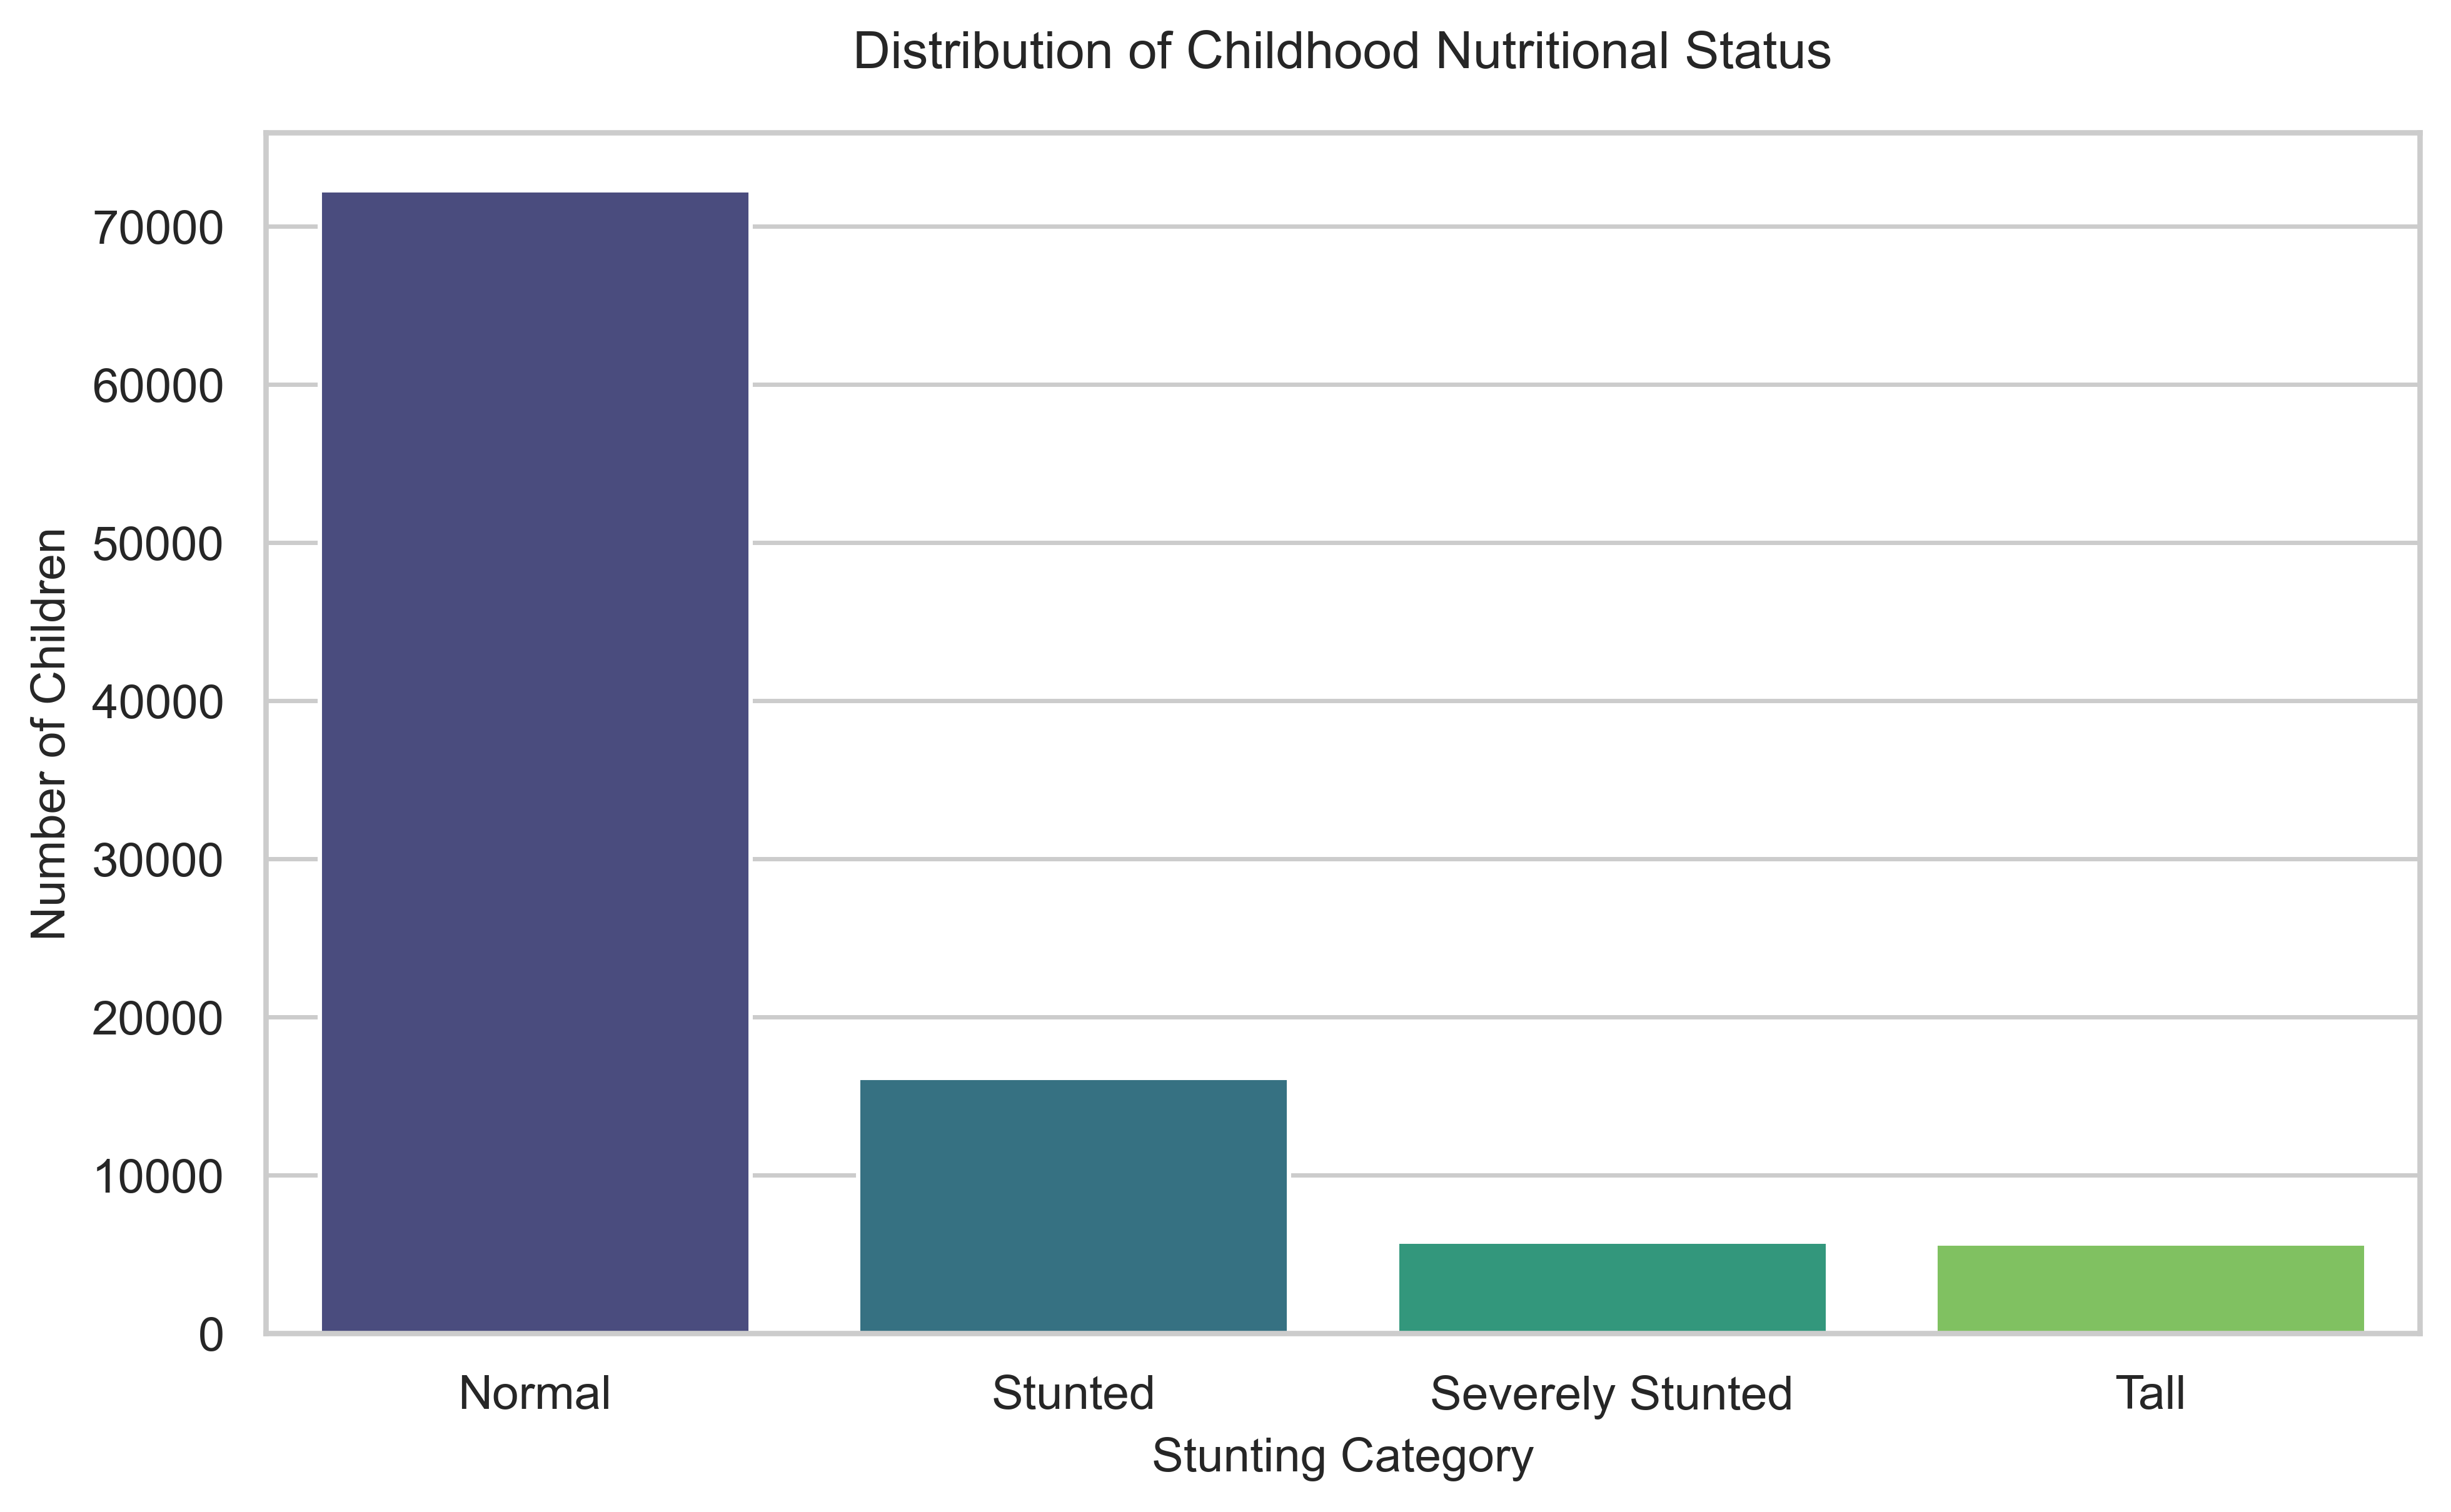

In [8]:
# 3.1 Distribusi Kelas Target Stunting
plt.figure(figsize=(8, 5))
sns.countplot(data=df_ml, x='Stunting', order=['Normal', 'Stunted', 'Severely Stunted', 'Tall'], palette='viridis')
plt.title('Distribution of Childhood Nutritional Status', fontsize=12, pad=15)
plt.xlabel('Stunting Category', fontsize=11)
plt.ylabel('Number of Children', fontsize=11)
plt.tight_layout()
plt.savefig('results/classification/stunting_class_distribution.png', dpi=500, bbox_inches='tight')
plt.show()

### 3.2 Physical Growth Curve: Height vs. Age
Scatter plot showing the distribution of children's height based on age and stunting status.

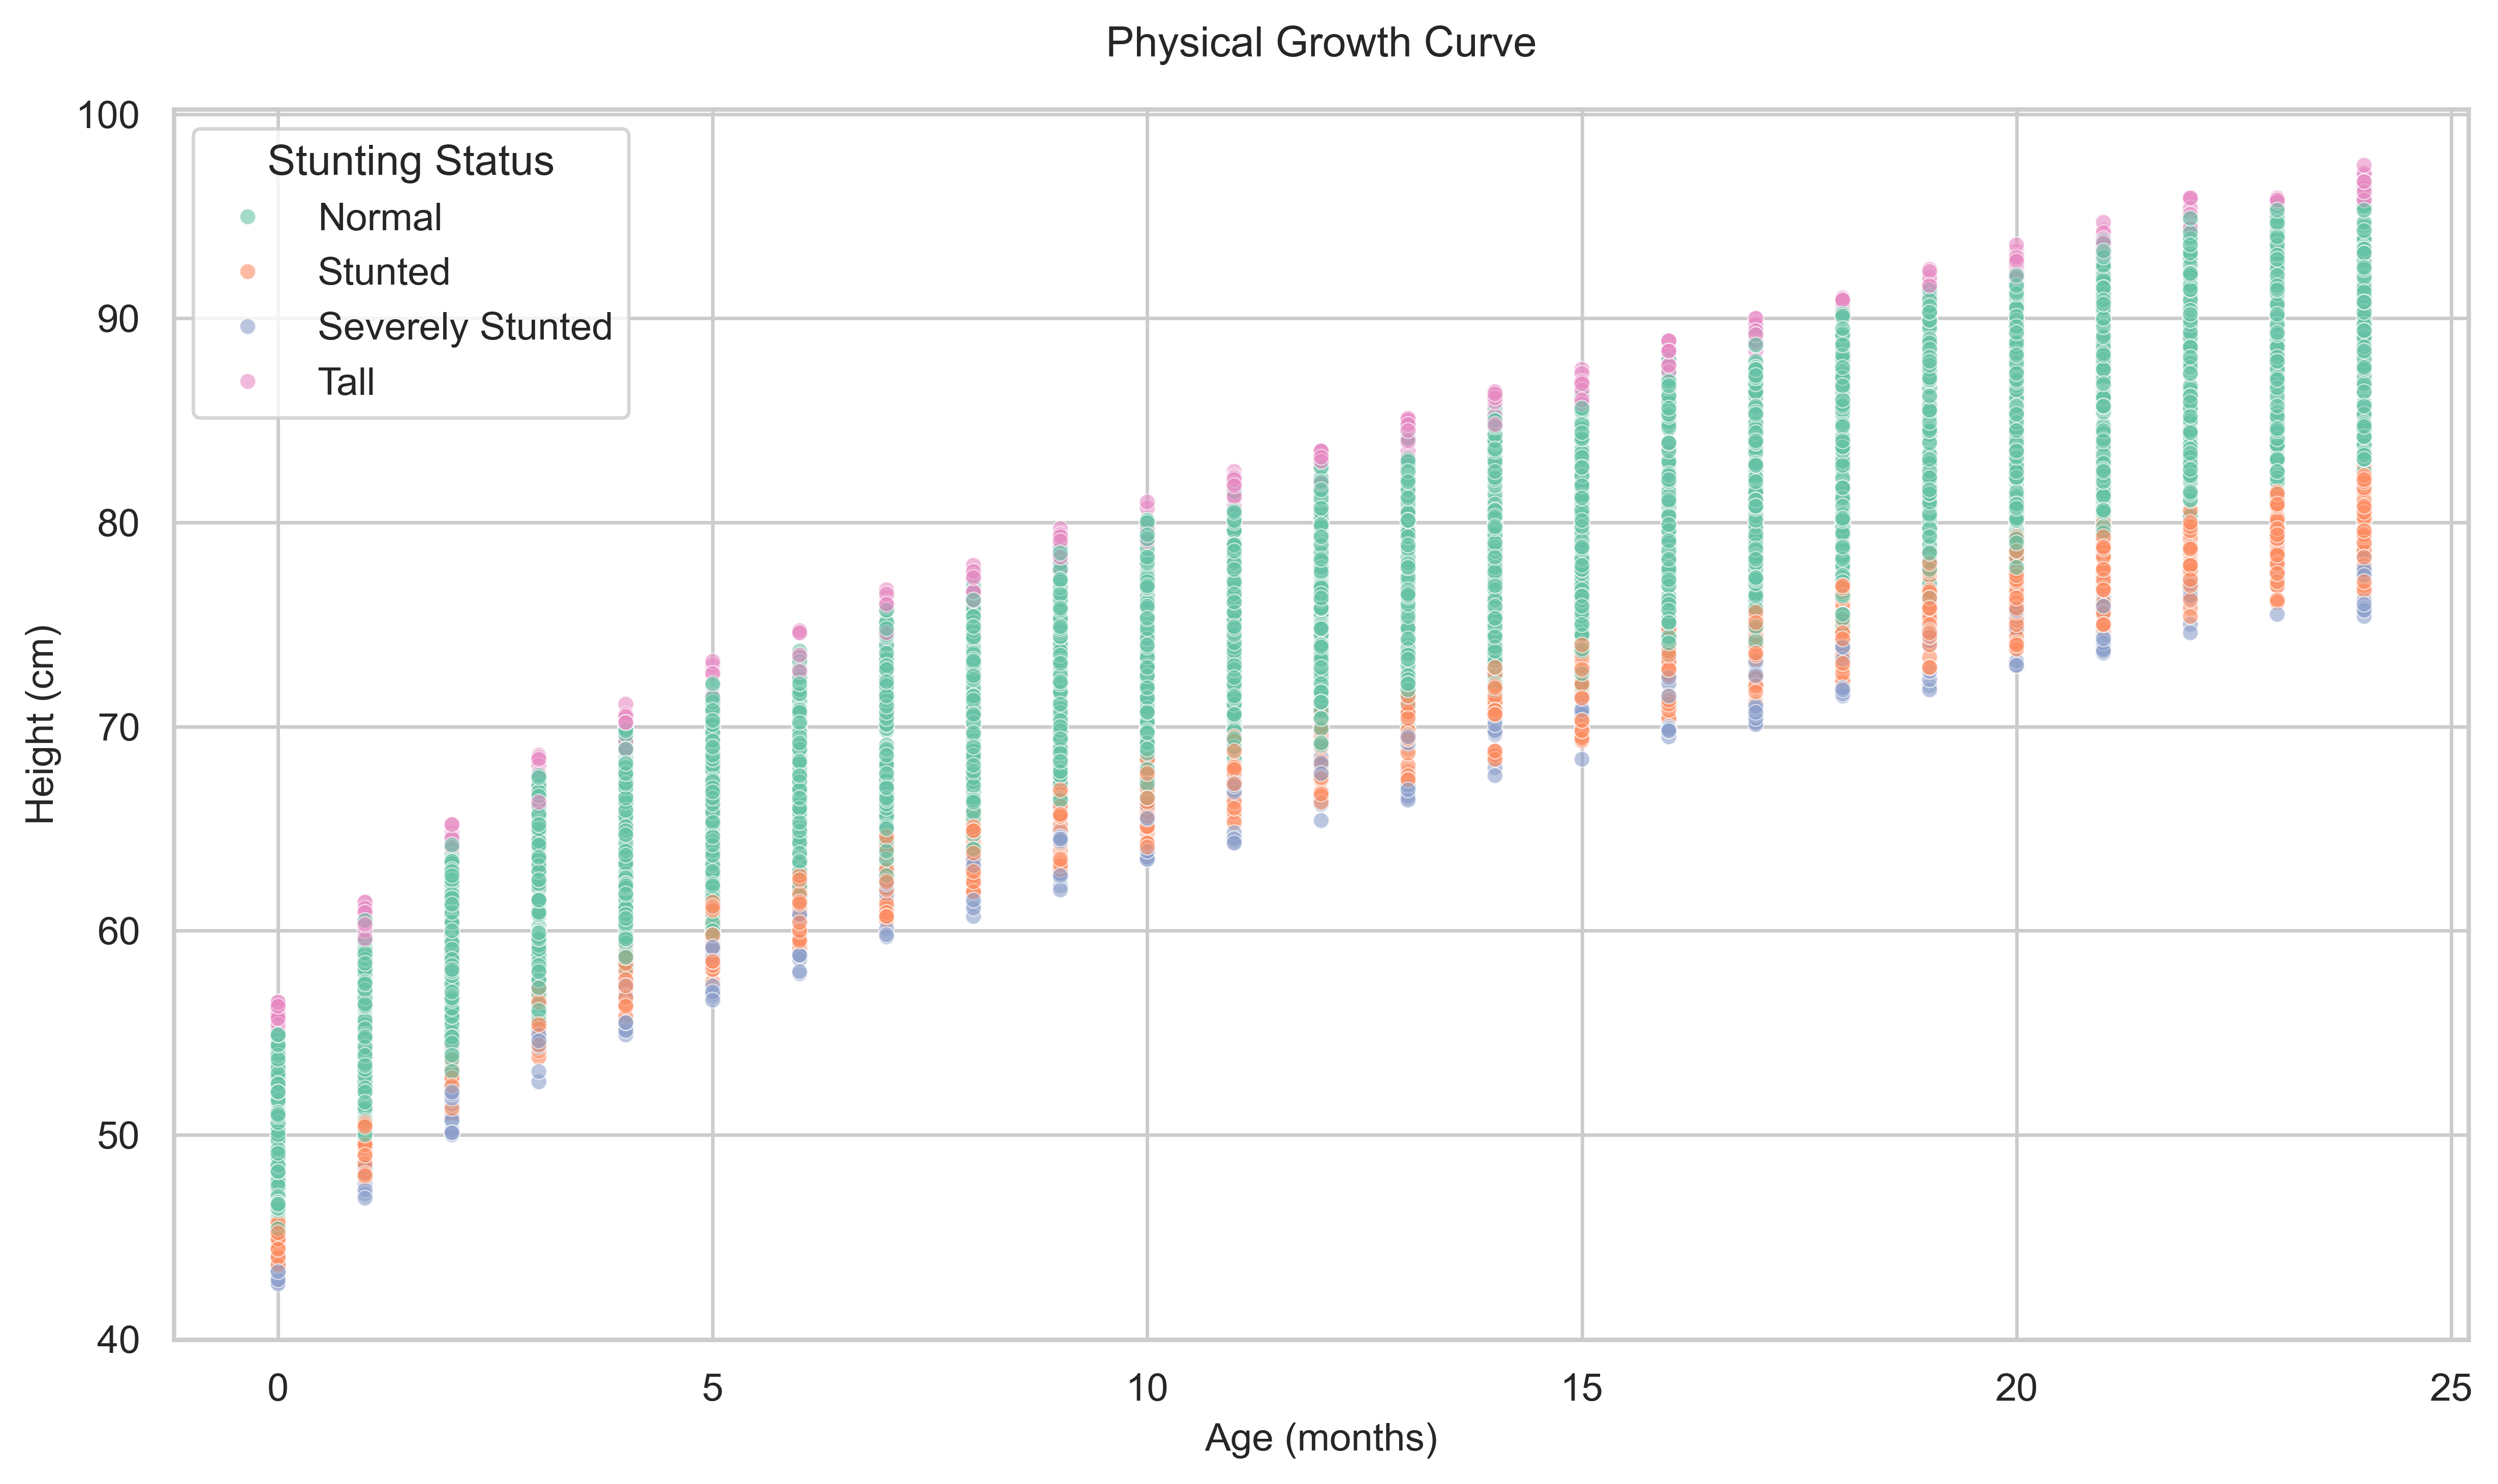

In [9]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_ml.sample(5000, random_state=42),
    x='Age (months)',
    y='Height (cm)',
    hue='Stunting',
    hue_order=['Normal', 'Stunted', 'Severely Stunted', 'Tall'],
    palette='Set2',
    alpha=0.6,
    s=20
)
plt.title('Physical Growth Curve', fontsize=12, pad=15)
plt.xlabel('Age (months)', fontsize=11)
plt.ylabel('Height (cm)', fontsize=11)
plt.legend(title='Stunting Status')
plt.tight_layout()
plt.savefig('results/classification/growth_curve.png', dpi=500, bbox_inches='tight')
plt.show()

## 4. Feature Engineering: Clinical Z-Score Extraction
Using the WHO LMS formula to dynamically compute HAZ and WAZ values based on reference tables.

In [10]:
def compute_z_scores(df_main, df_who_lhfa, df_who_wfa):
    original_index = df_main.index

    # 1. HAZ
    df_merged = pd.merge(df_main, df_who_lhfa[['c', 'L', 'M', 'S']], left_on='Age (months)', right_on='c', how='left')
    X_h = df_merged['Height (cm)']
    L_h = df_merged['L']
    M_h = df_merged['M']
    S_h = df_merged['S']
    df_merged['HAZ'] = (((X_h / M_h) ** L_h) - 1) / (L_h * S_h)
    df_merged = df_merged.drop(columns=['c', 'L', 'M', 'S'])

    # 2. WAZ
    df_merged = pd.merge(df_merged, df_who_wfa[['c', 'L', 'M', 'S']], left_on='Age (months)', right_on='c', how='left')
    X_w = df_merged['Weight (kg)']
    L_w = df_merged['L']
    M_w = df_merged['M']
    S_w = df_merged['S']
    df_merged['WAZ'] = np.where(L_w == 0,
                                np.log(X_w / M_w) / S_w,
                                (((X_w / M_w) ** L_w) - 1) / (L_w * S_w))
    df_merged = df_merged.drop(columns=['c', 'L', 'M', 'S'])

    df_merged.index = original_index
    return df_merged

df_boys = df_ml[df_ml['Gender'] == 'Male'].copy()
df_girls = df_ml[df_ml['Gender'] == 'Female'].copy()

df_boys_enriched = compute_z_scores(df_boys, who_lhfa_boys, who_wfa_boys)
df_girls_enriched = compute_z_scores(df_girls, who_lhfa_girls, who_wfa_girls)

df_final = pd.concat([df_boys_enriched, df_girls_enriched]).sort_index()
df_final.head()

,Gender,Age (months),Height (cm),Weight (kg),Stunting,Wasting,HAZ,WAZ
0,Male,19,91.6,13.3,Tall,Risk of Overweight,3.033495,1.587105
1,Male,20,77.7,8.5,Stunted,Underweight,-2.309778,-2.572957
2,Male,10,79.0,10.3,Normal,Risk of Overweight,2.502858,1.077254
3,Female,2,50.3,8.3,Severely Stunted,Risk of Overweight,-3.323558,3.790974
4,Female,5,56.4,10.9,Severely Stunted,Risk of Overweight,-3.441070,3.690638


In [11]:
# Label Encoding for Gender and Target
gender_encoder = LabelEncoder()
df_final['Gender_Encoded'] = gender_encoder.fit_transform(df_final['Gender'])

stunting_encoder = LabelEncoder()
df_final['Stunting_Encoded'] = stunting_encoder.fit_transform(df_final['Stunting'])

# Definisikan Target
y = df_final['Stunting_Encoded']


# Definisikan Fitur Antropometri Fisik
X_clean = df_final[['Gender_Encoded', 'Age (months)', 'Height (cm)', 'Weight (kg)']]

print("Data preprocessing completed!")

Data preprocessing completed!


## 5. Robust Classification Pipeline Implementation (Stratified 5-Fold CV & Class Weights)
We train the classification models using clean anthropometric features (excluding computed Z-scores). We implement **Stratified 5-Fold Cross Validation** for scientific validation and handle class imbalance using class weights.

In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f1_clean = {}
trained_clean_models = {}

print("Evaluating Clean Pipeline using Stratified 5-Fold Cross Validation:")

results = []
complexity_mapping = {
    'Random Forest': 'Default Regularization (50 Trees)',
    'Extra Trees': 'Default Regularization (50 Trees)',
    'XGBoost': 'Gradient Boosting (100 Trees, Depth=6)',
    'LightGBM': 'Gradient Boosting (100 Trees, Leaves=31)',
    'CatBoost': 'Gradient Boosting (1000 Trees, Depth=6)'
}

for name in ['Random Forest', 'Extra Trees', 'XGBoost', 'LightGBM', 'CatBoost']:
    fold_acc = []
    fold_prec = []
    fold_rec = []
    fold_f1 = []
    fold_auc = []

    for fold, (train_idx, test_idx) in enumerate(cv.split(X_clean, y)):
        X_tr, X_val = X_clean.iloc[train_idx], X_clean.iloc[test_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[test_idx]

        # Initialize model with imbalance handling
        if name == 'Random Forest':
            model = RandomForestClassifier(n_estimators=50, class_weight='balanced', random_state=42, n_jobs=-1)
            model.fit(X_tr, y_tr)
        elif name == 'Extra Trees':
            model = ExtraTreesClassifier(n_estimators=50, class_weight='balanced', random_state=42, n_jobs=-1)
            model.fit(X_tr, y_tr)
        elif name == 'XGBoost':
            model = XGBClassifier(random_state=42, eval_metric='mlogloss', n_jobs=-1)
            w = compute_sample_weight(class_weight='balanced', y=y_tr)
            model.fit(X_tr, y_tr, sample_weight=w)
        elif name == 'LightGBM':
            model = LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1, n_jobs=-1)
            model.fit(X_tr, y_tr)
        elif name == 'CatBoost':
            model = CatBoostClassifier(auto_class_weights='Balanced', random_seed=42, verbose=0)
            model.fit(X_tr, y_tr)

        preds = model.predict(X_val)
        probs = model.predict_proba(X_val)

        fold_acc.append(accuracy_score(y_val, preds))
        fold_prec.append(precision_score(y_val, preds, average='weighted'))
        fold_rec.append(recall_score(y_val, preds, average='weighted'))
        fold_f1.append(f1_score(y_val, preds, average='weighted'))
        fold_auc.append(roc_auc_score(y_val, probs, multi_class='ovr', average='weighted'))

    mean_f1 = np.mean(fold_f1)
    std_f1 = np.std(fold_f1)
    f1_clean[name] = mean_f1

    # Train the final model on all clean data for deployment
    if name == 'XGBoost':
        final_xgb = XGBClassifier(random_state=42, eval_metric='mlogloss', n_jobs=-1)
        w_full = compute_sample_weight(class_weight='balanced', y=y)
        final_xgb.fit(X_clean, y, sample_weight=w_full)
        trained_clean_models['XGBoost'] = final_xgb

    results.append({
        'Classification Model': name,
        'Accuracy': np.mean(fold_acc),
        'Weighted Precision': np.mean(fold_prec),
        'Weighted Recall': np.mean(fold_rec),
        'Weighted F1-Score': mean_f1,
        'Weighted AUC-ROC': np.mean(fold_auc),
        'SD F1-Score': f"± {std_f1:.4f}",
        'Model Complexity': complexity_mapping[name]
    })

    print(f"- {name} Weighted F1-Score: {mean_f1:.6f} +/- {std_f1:.6f}")

# Display performance comparison table as a styled DataFrame
df_results = pd.DataFrame(results)
for col in ['Accuracy', 'Weighted Precision', 'Weighted Recall', 'Weighted F1-Score', 'Weighted AUC-ROC']:
    df_results[col] = df_results[col].map(lambda x: f"{x:.4f}")

df_results


Evaluating Clean Pipeline using Stratified 5-Fold Cross Validation:
- Random Forest Weighted F1-Score: 0.999780 +/- 0.000051
- Extra Trees Weighted F1-Score: 0.998450 +/- 0.000331
- XGBoost Weighted F1-Score: 0.987701 +/- 0.000425
- LightGBM Weighted F1-Score: 0.986230 +/- 0.000966
- CatBoost Weighted F1-Score: 0.964969 +/- 0.003603


,Classification Model,Accuracy,Weighted Precision,Weighted Recall,Weighted F1-Score,Weighted AUC-ROC,SD F1-Score,Model Complexity
0,Random Forest,0.9998,0.9998,0.9998,0.9998,1.0000,± 0.0001,Default Regularization (50 Trees)
1,Extra Trees,0.9985,0.9985,0.9985,0.9984,1.0000,± 0.0003,Default Regularization (50 Trees)
2,XGBoost,0.9876,0.9881,0.9876,0.9877,0.9998,± 0.0004,"Gradient Boosting (100 Trees, Depth=6)"
3,LightGBM,0.9861,0.9867,0.9861,0.9862,0.9996,± 0.0010,"Gradient Boosting (100 Trees, Leaves=31)"
4,CatBoost,0.9637,0.9693,0.9637,0.9650,0.9991,± 0.0036,"Gradient Boosting (1000 Trees, Depth=6)"


## 6. Detailed Analysis of the Best Model (XGBoost)
Displays the complete classification report for the XGBoost model.

In [13]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clean, y, test_size=0.2, random_state=42)

# Train evaluation model on training set (for clean classification report)
eval_model = XGBClassifier(random_state=42, eval_metric='mlogloss', n_jobs=-1)
w_train = compute_sample_weight(class_weight='balanced', y=y_train_c)
eval_model.fit(X_train_c, y_train_c, sample_weight=w_train)
clean_preds = eval_model.predict(X_test_c)

print("Classification Report XGBoost:")
print(classification_report(y_test_c, clean_preds, target_names=stunting_encoder.classes_))

# Save best_model for subsequent steps (SHAP & Serialization)
best_model = trained_clean_models['XGBoost']


Classification Report XGBoost:
                  precision    recall  f1-score   support

          Normal       1.00      0.99      0.99     14406
Severely Stunted       0.96      0.99      0.97      1146
         Stunted       0.97      0.98      0.97      3292
            Tall       0.92      1.00      0.96      1156

        accuracy                           0.99     20000
       macro avg       0.96      0.99      0.97     20000
    weighted avg       0.99      0.99      0.99     20000



### 6.1 XGBoost Confusion Matrix Visualization (500 DPI)
Confusion matrix showing the comparison between actual and predicted nutritional categories for children.

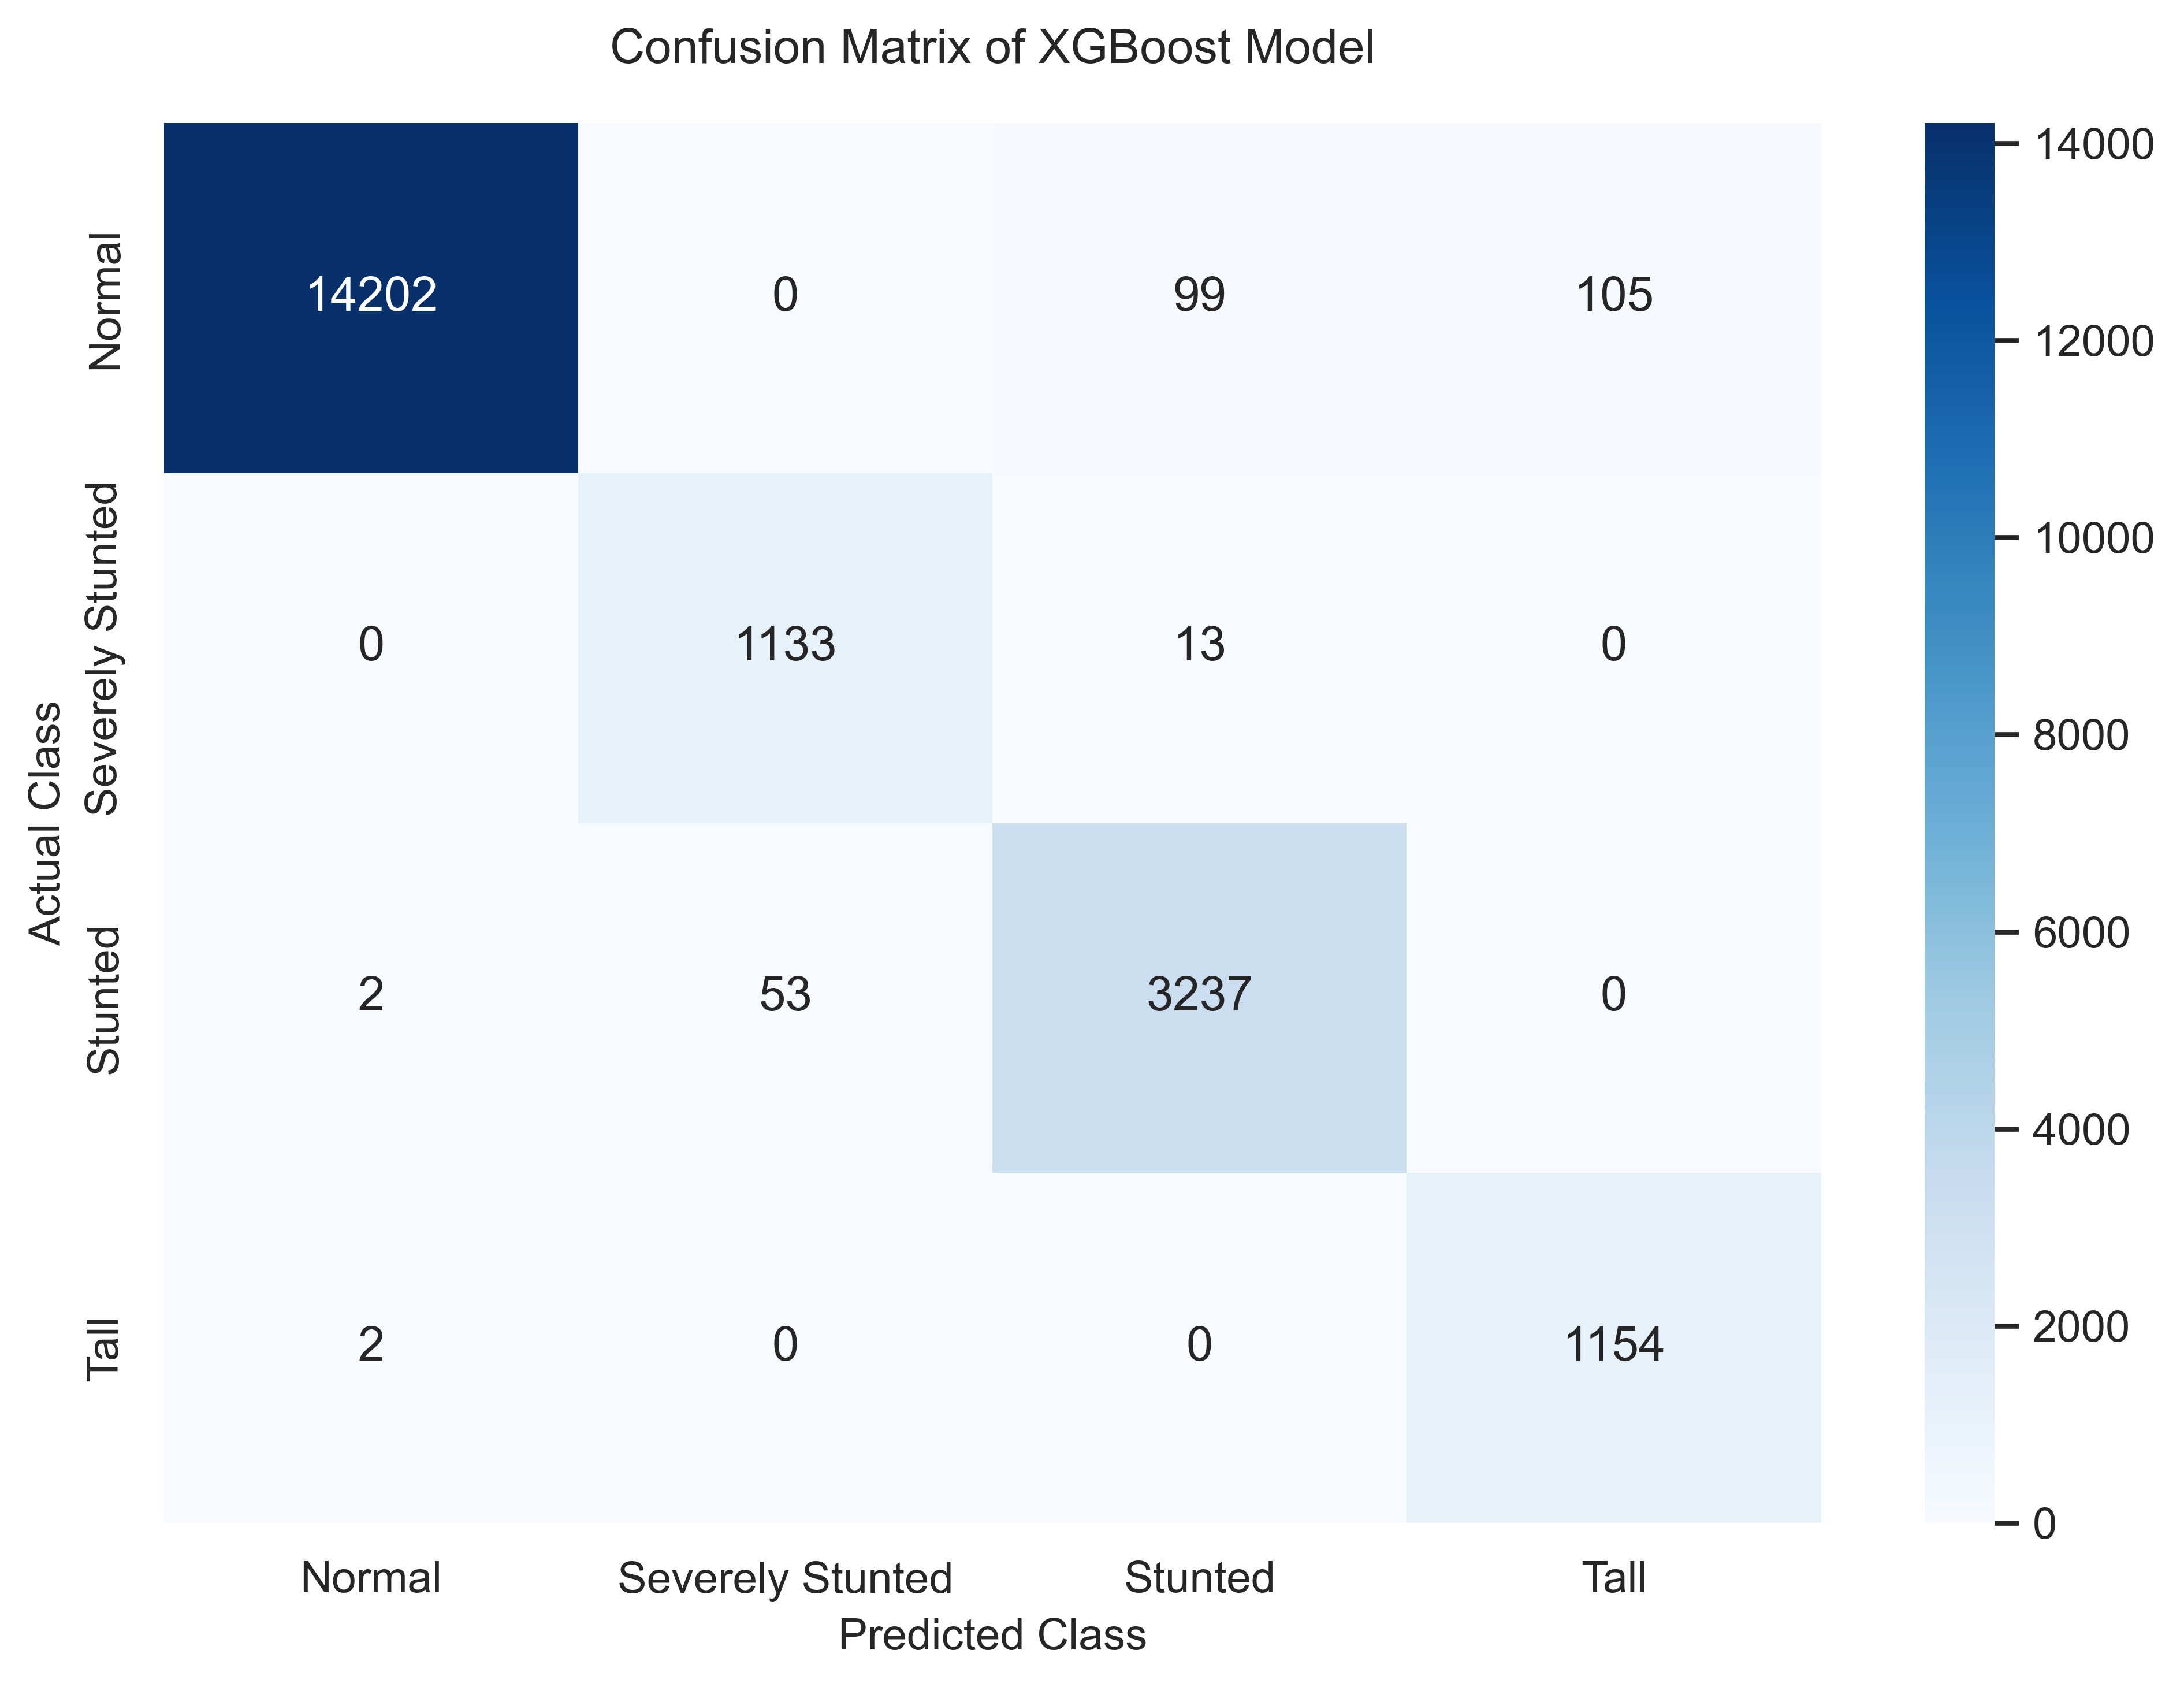

In [14]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_c, clean_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=stunting_encoder.classes_,
            yticklabels=stunting_encoder.classes_)
plt.title('Confusion Matrix of XGBoost Model', fontsize=12, pad=15)
plt.xlabel('Predicted Class', fontsize=11)
plt.ylabel('Actual Class', fontsize=11)
plt.tight_layout()
plt.savefig('results/classification/xgboost_confusion_matrix.png', dpi=500, bbox_inches='tight')
plt.show()

## 7. Clinical Interpretability Using SHAP
Using global SHAP summary plots and local waterfall plots to interpret the model's prediction logic from a medical perspective.

Stunted class index: 2


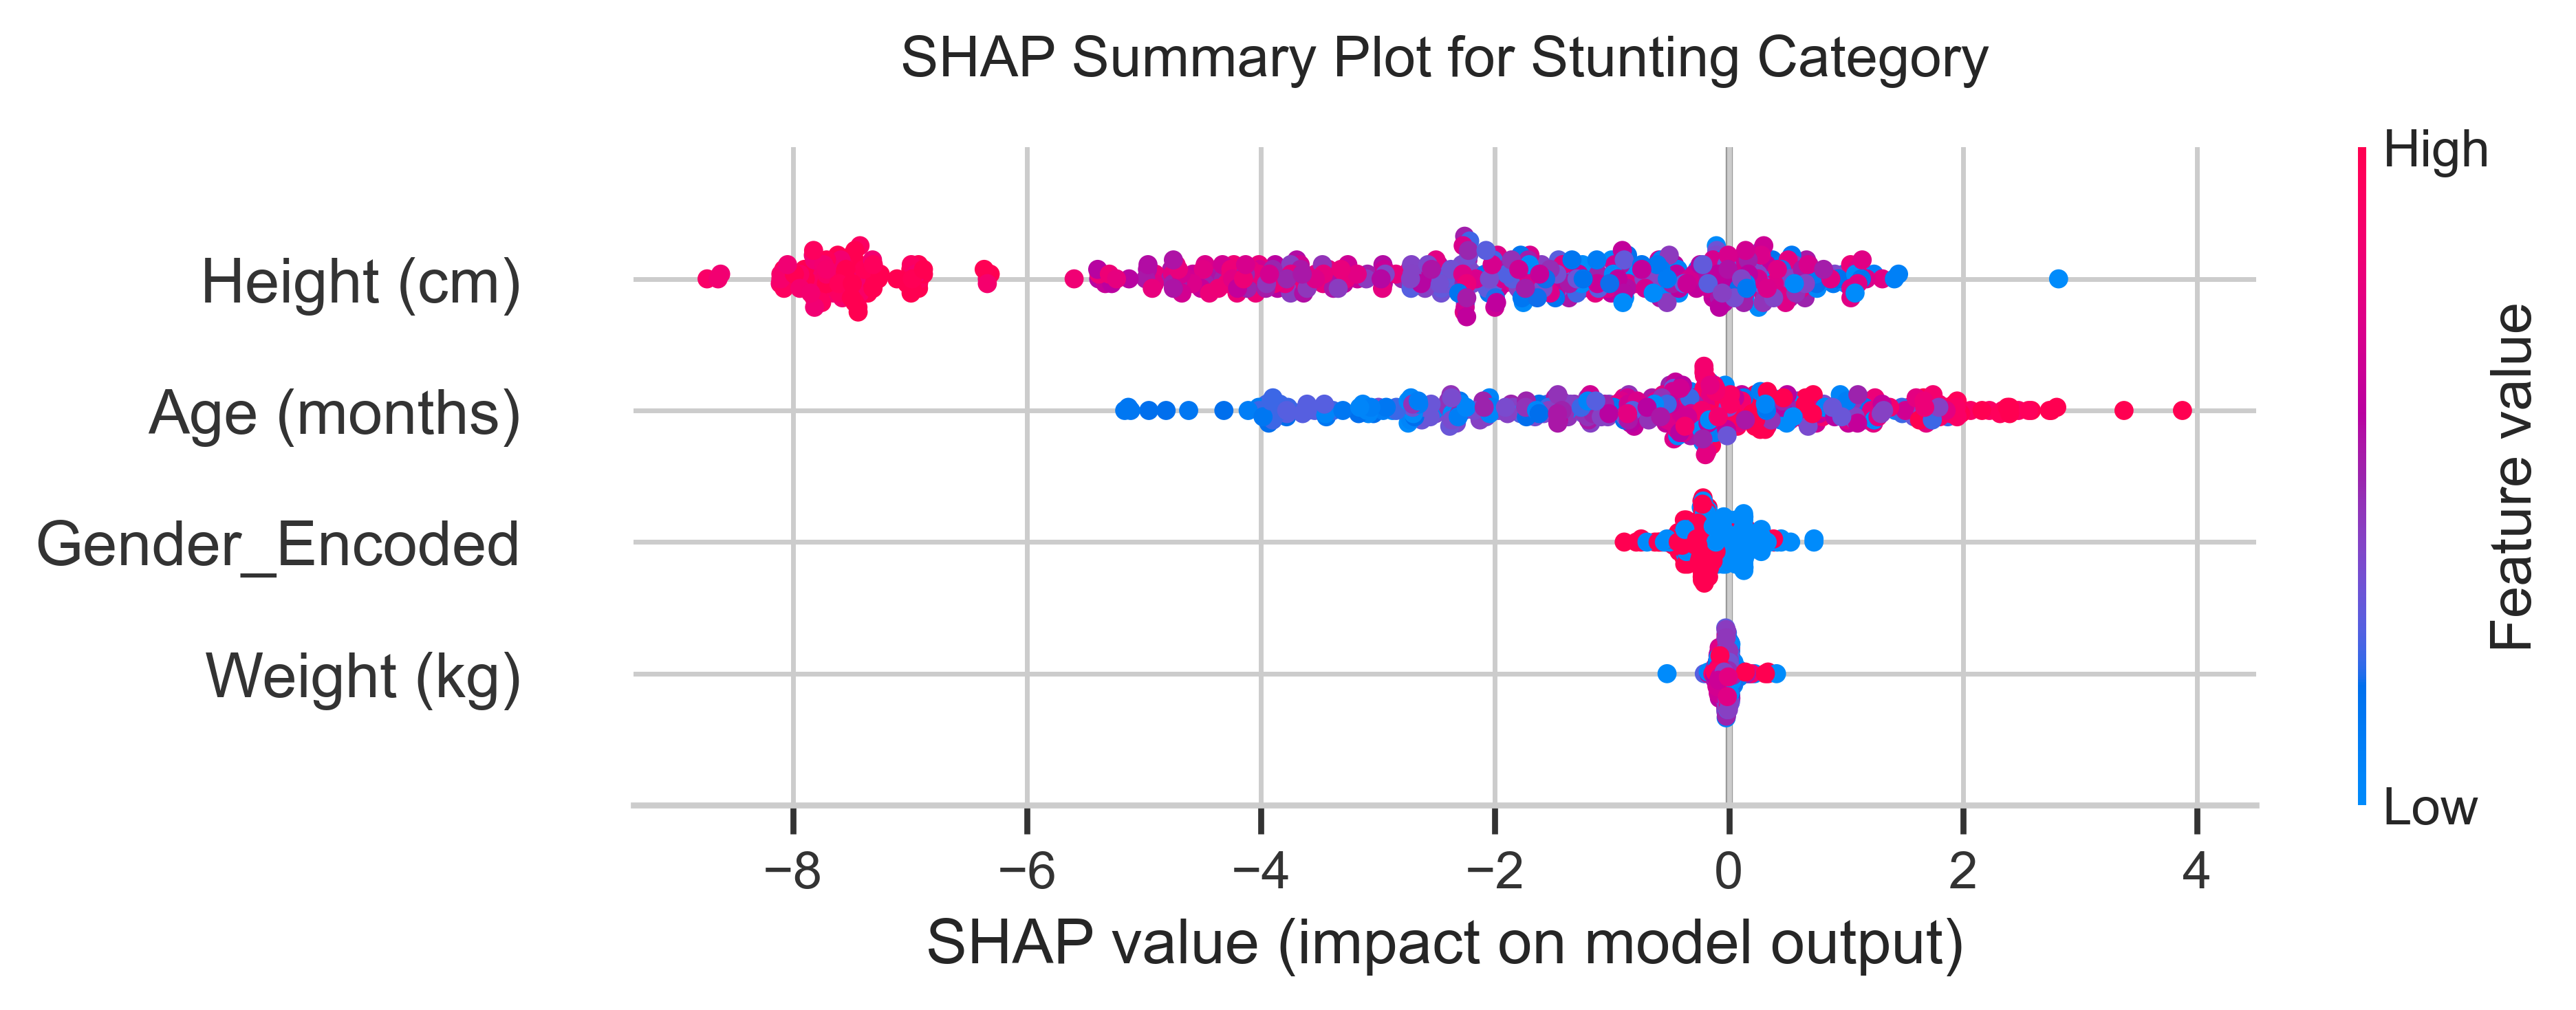

In [15]:
explainer = shap.TreeExplainer(best_model)
X_sample = X_test_c.sample(500, random_state=42)
shap_values = explainer(X_sample)

stunted_idx = list(stunting_encoder.classes_).index('Stunted')
print(f"Stunted class index: {stunted_idx}")

# Global Summary Plot for the Stunted class
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values.values[:, :, stunted_idx], X_sample, show=False)
plt.title('SHAP Summary Plot for Stunting Category', fontsize=12, pad=15)
plt.tight_layout()
plt.savefig('results/classification/classification_shap_summary.png', dpi=500, bbox_inches='tight')
plt.show()

### 7.1 Local Diagnostic Analysis for Child A (SHAP Waterfall Plot)
Detailed explanation of feature contributions for a specific child predicted as 'Stunted'.

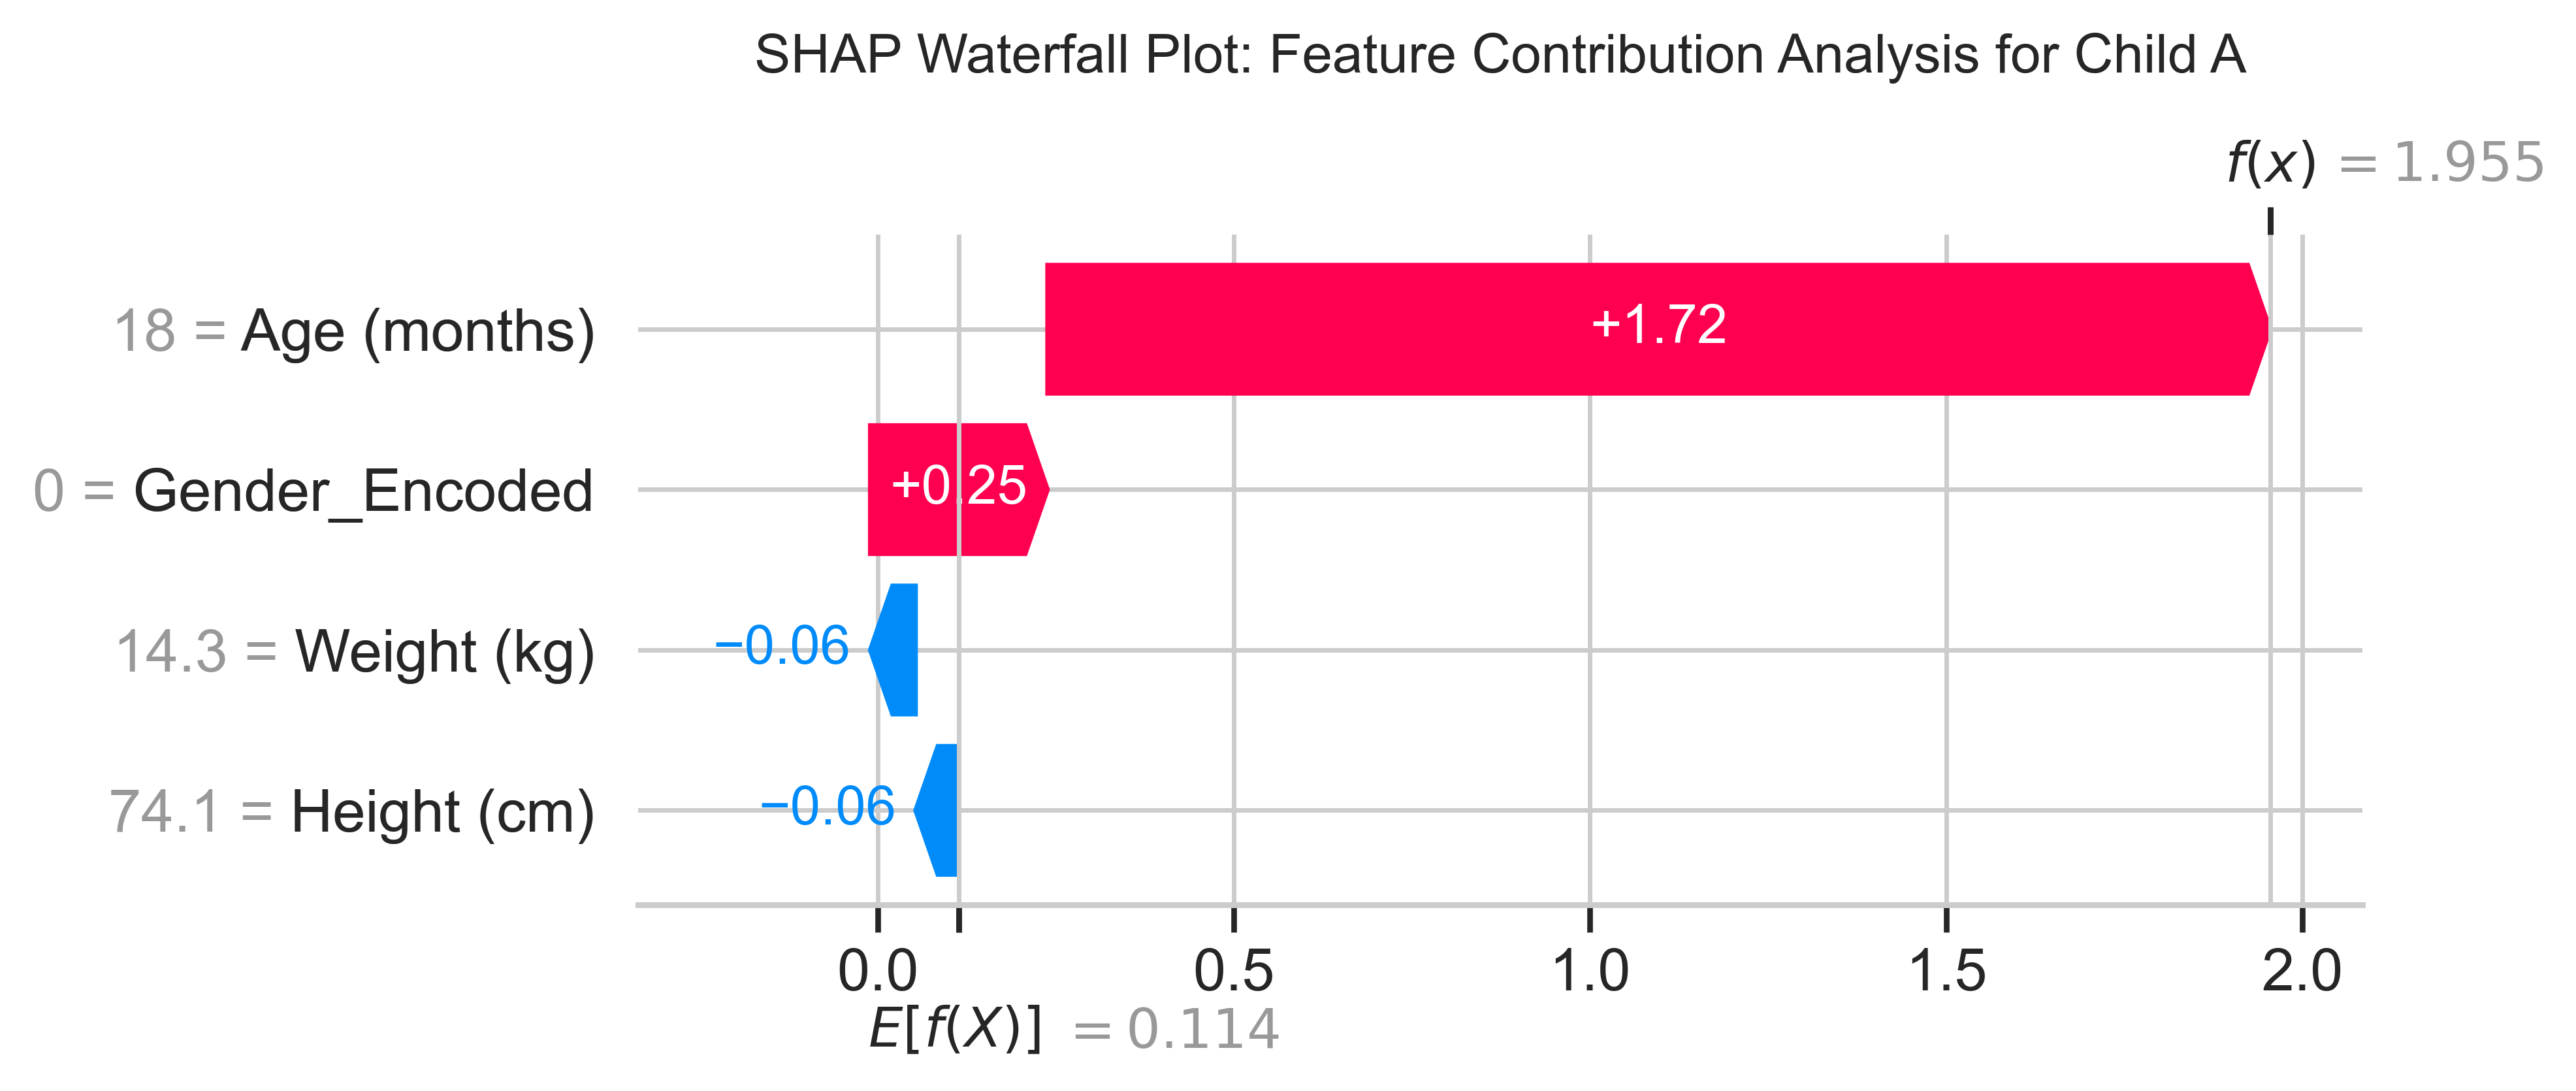

In [16]:
# Select the first child sample predicted as Stunted
stunted_samples = X_test_c[clean_preds == stunted_idx]
if len(stunted_samples) > 0:
    idx_sample = stunted_samples.index[0]
    single_sample = X_test_c.loc[[idx_sample]]
    single_shap = explainer(single_sample)

    # Construct SHAP explanation object for the Stunted class
    exp = shap.Explanation(
        values=single_shap.values[0, :, stunted_idx],
        base_values=single_shap.base_values[0, stunted_idx] if hasattr(single_shap.base_values, '__len__') else single_shap.base_values,
        data=single_sample.iloc[0].values,
        feature_names=X_clean.columns.tolist()
    )

    plt.figure(figsize=(10, 5))
    shap.plots.waterfall(exp, show=False)
    plt.title('SHAP Waterfall Plot: Feature Contribution Analysis for Child A', fontsize=12, pad=15)
    plt.tight_layout()
    plt.savefig('results/classification/classification_shap_waterfall.png', dpi=500, bbox_inches='tight')
    plt.show()
else:
    print("No stunted samples found for waterfall visualization.")

## 8. Model Serialization & Production Inference Pipeline (MLOps)
Saves the trained model and encoders to disk and provides a self-inference function with biological input validation.

In [17]:
# Save model and encoder
joblib.dump(best_model, 'results/classification/stunting_xgb_classifier.joblib')
joblib.dump(stunting_encoder, 'results/classification/stunting_target_encoder.joblib')
joblib.dump(gender_encoder, 'results/classification/stunting_gender_encoder.joblib')
print("Model and encoders saved successfully to results/classification/!")

# Self-Inference Pipeline with GIGO Protection
def diagnose_child(gender, age_months, height_cm, weight_kg):
    # 1. Proteksi batas biologis input
    if not (0 <= age_months <= 60):
        raise ValueError("Child's age must be within the biological range of 0 to 60 months.")
    if not (30 <= height_cm <= 120):
        raise ValueError("Height must be within the biological range of 30 to 120 cm.")
    if not (2 <= weight_kg <= 30):
        raise ValueError("Weight must be within the biological range of 2 to 30 kg.")
    if gender not in ['Male', 'Female']:
        raise ValueError("Gender must be 'Male' or 'Female'.")

    # 2. Transformasi input
    gender_enc = gender_encoder.transform([gender])[0]
    input_data = pd.DataFrame([{
        'Gender_Encoded': gender_enc,
        'Age (months)': age_months,
        'Height (cm)': height_cm,
        'Weight (kg)': weight_kg
    }])

    # 3. Prediksi
    pred_idx = best_model.predict(input_data)[0]
    pred_class = stunting_encoder.inverse_transform([pred_idx])[0]
    pred_proba = best_model.predict_proba(input_data)[0]
    confidence = pred_proba[pred_idx] * 100

    return pred_class, confidence

# Contoh pengujian inferensi baru
status, conf = diagnose_child(gender='Male', age_months=18, height_cm=70.5, weight_kg=8.5)
print(f"Test Child Diagnosis Result: {status} (Confidence: {conf:.2f}%)")

Model and encoders saved successfully to results/classification/!
Test Child Diagnosis Result: Severely Stunted (Confidence: 100.00%)
